<h2>Setup</h2>


In [16]:
# uncomment the next line if running in a notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

G = 6.67 * 10**-11  # gravitational constant
M = 6.42 * 10**23  # mass of Mars

<h2>Define Euler </h2>


In [17]:
def Euler(g_m, g_k, g_r, g_v, g_t_max, g_dt):
    
    # mass, spring constant, initial position and velocity
    m = g_m
    k = g_k
    r = g_r
    v = g_v

    # simulation time, timestep and time
    t_max = g_t_max
    dt = g_dt
    t_array = np.arange(0, g_t_max, g_dt)

    # initialise empty lists to record trajectories
    r_list = []
    v_list = []

    # Euler integration
    for t in t_array:

        # append current state to trajectories
        r_list.append(r)
        v_list.append(v)

        # calculate new position and velocity
        a = (-G * M * g_m) / (np.linalg.norm(g_r) ** 3) * g_r 
        r = r + dt * v
        v = v + dt * a
    # convert trajectory lists into arrays, so they can be sliced (useful for Assignment 2)
    r_array = np.array(r_list)
    v_array = np.array(v_list)
    return r_array, v_array

<h2>Define Verlet</h2>


In [18]:
def Verlet(g_m, g_k, g_r, g_v, g_t_max, g_dt):
    
    # mass, spring constant, initial position and velocity
    m = g_m
    k = g_k
    r = g_r
    v = g_v

    # simulation time, timestep and time
    t_max = g_t_max
    dt = g_dt
    t_array = np.arange(0, t_max, dt)


    xplus1 = g_x + v * dt

    # initialise empty lists to record trajectories
    x_list = []
    v_list = []
    
    for t in range(1,len(t_array)):
        if not x_list:
            x_list.append(x)
            x_list.append(xplus1)
            # v_list.append(v)
            continue
        x_list.append(x)
        
        a = -k * x / m
        x = 2 * x - x_list[t-1] + dt**2 * a
    
    return x_list

<h2>Initial Tests</h2>
<p> First with intial dt = 0.1</p>


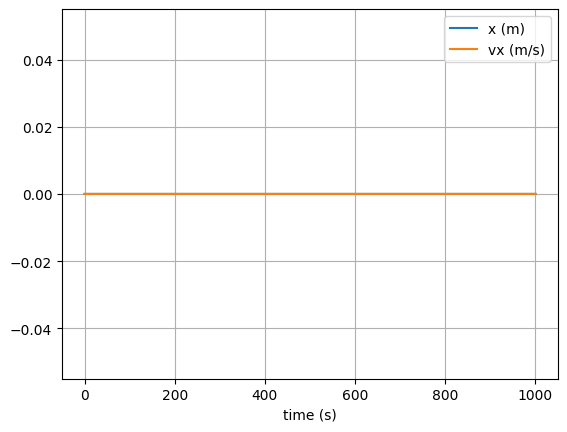

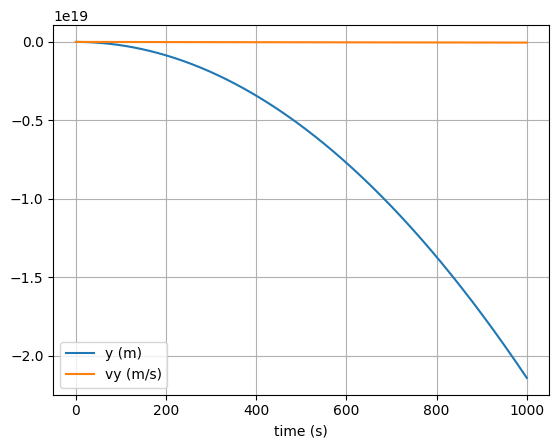

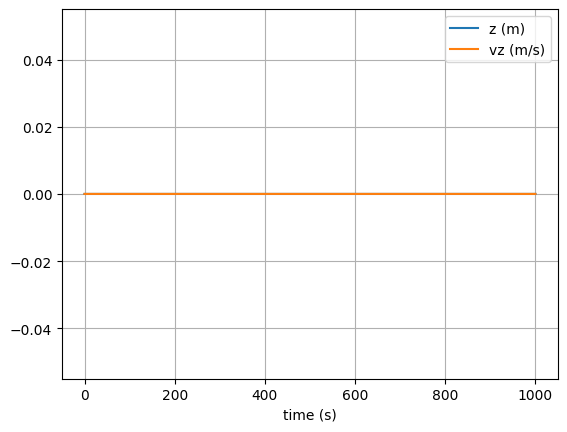

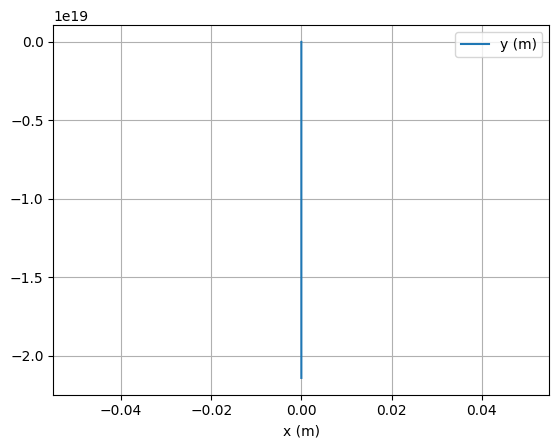

In [29]:

def testEstimates(g_m, g_k, g_r, g_v, g_t_max, g_dt, EulerFlag=True, VerletFlag=True):

    g_t_array = np.arange(0, g_t_max, g_dt)
    
    if EulerFlag:
        x_array, v_array = Euler(g_m, g_k, g_r, g_v, g_t_max, g_dt)
    if VerletFlag:
        vx_array = Verlet(g_m, g_k, g_r, g_v, g_t_max, g_dt)

    # plot the position-time graph
    plt.figure(1)
    plt.clf()
    plt.xlabel('time (s)')
    plt.grid()
    labels = ["x", "y", "z"]
    if EulerFlag:
        for i in range(3):
            plt.clf()
            plt.xlabel('time (s)')
            plt.grid()
            plt.plot(g_t_array, x_array[:,i], label=f'{labels[i]} (m)')
            plt.plot(g_t_array, v_array[:,i], label=f'v{labels[i]} (m/s)')
            plt.legend()
            plt.show()
        plt.clf()
        plt.xlabel('x (m)')
        plt.grid()
        plt.plot(x_array[:,0], x_array[:,1], label='y (m)')
        plt.legend()
        plt.show()
    if VerletFlag:
        plt.plot(g_t_array, vx_array, label='verlet x (m)')


testEstimates(1, 1, np.array([0,1,0]), np.array([0,-0.5,0]), 1000, 0.1, True, False)